**13 LARGE DATASET GENERATION**

In [1]:
# ============================================================
# TBM-X — 13 LARGE DATASET GENERATION
# ============================================================
#
# Purpose:
# Generate a physics-informed synthetic aircraft design
# dataset for the TBM-X Data Science pipeline.
#
# The dataset will be generated from the aircraft physics model
# rather than from arbitrary random numbers.
#
# Main workflow:
#
#   Design Variables
#          ↓
#   Sampling Strategy
#          ↓
#   Physics Model
#          ↓
#   Performance Calculation
#          ↓
#   Feasibility Checks
#          ↓
#   Valid Design Dataset
#
# This dataset will later be used for:
#
#   EDA
#   ML / Surrogate Modeling
#   Uncertainty Quantification
#   Optimization
#   Engineering Decision
#
# IMPORTANT:
#
# Benchmark aircraft are NOT used to generate the synthetic
# samples.
#
# Benchmark data will be used later for validation..
#
# ============================================================

**Librairies**

In [2]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("✓ Libraries imported.")

✓ Libraries imported.


**Working Directory**

In [3]:
# ============================================================
# CELL 3 — WORKING DIRECTORY
# ============================================================

PROJECT_ROOT = Path.cwd()

print("Project root:")
print(PROJECT_ROOT)

Project root:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering


**Output Directory**

In [4]:
# ============================================================
# CELL 4 — OUTPUT DIRECTORY
# ============================================================

dataset_output_dir = (
    PROJECT_ROOT
    / "data"
    / "generated"
)

dataset_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Dataset output directory:")
print(dataset_output_dir)

Dataset output directory:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\data\generated


**Dataset Configuration**

In [5]:
# ============================================================
# CELL 5 — DATASET CONFIGURATION
# ============================================================

N_SAMPLES = 10_000

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print(f"Number of requested samples : {N_SAMPLES}")
print(f"Random seed                 : {RANDOM_SEED}")

Number of requested samples : 10000
Random seed                 : 42


**Design Variables**

In [6]:
# ============================================================
# CELL 6 — DESIGN VARIABLES
# ============================================================
#
# These are the variables that define a candidate aircraft.
#
# They are deliberately limited to a manageable set in v0.1.
#
# Later versions can add:
#   - taper ratio
#   - tail volume
#   - propeller diameter
#   - altitude power lapse parameters
#   - structural parameters
#   - etc.
# ============================================================

design_variable_ranges = {
    
    "MTOW_kg": (2800.0, 5000.0),
    
    "Wing_Area_m2": (14.0, 24.0),
    
    "Aspect_Ratio": (7.0, 11.0),
    
    "Cruise_Speed_kt": (260.0, 340.0),
    
    "Cruise_Altitude_ft": (15000.0, 30000.0),
    
    "Engine_Power_kW": (500.0, 850.0),
    
    "CD0": (0.020, 0.032),
    
    "Oswald_Efficiency": (0.72, 0.88),
    
    "Propeller_Efficiency": (0.78, 0.90),
    
    "BSFC_kg_kWh": (0.26, 0.34),
    
    "CLmax": (1.60, 2.00),
}

design_variable_ranges

{'MTOW_kg': (2800.0, 5000.0),
 'Wing_Area_m2': (14.0, 24.0),
 'Aspect_Ratio': (7.0, 11.0),
 'Cruise_Speed_kt': (260.0, 340.0),
 'Cruise_Altitude_ft': (15000.0, 30000.0),
 'Engine_Power_kW': (500.0, 850.0),
 'CD0': (0.02, 0.032),
 'Oswald_Efficiency': (0.72, 0.88),
 'Propeller_Efficiency': (0.78, 0.9),
 'BSFC_kg_kWh': (0.26, 0.34),
 'CLmax': (1.6, 2.0)}

**Design Variable Documentation**

In [7]:
# ============================================================
# CELL 7 — DESIGN VARIABLE DOCUMENTATION
# ============================================================

design_variable_info = pd.DataFrame({
    
    "Variable": list(
        design_variable_ranges.keys()
    ),
    
    "Minimum": [
        value[0]
        for value in design_variable_ranges.values()
    ],
    
    "Maximum": [
        value[1]
        for value in design_variable_ranges.values()
    ],
    
    "Role": [
        "Aircraft size / weight",
        "Wing sizing",
        "Wing geometry",
        "Cruise condition",
        "Cruise condition",
        "Propulsion sizing",
        "Parasite drag",
        "Aerodynamic efficiency",
        "Propeller efficiency",
        "Fuel consumption",
        "Low-speed capability",
    ]
})

design_variable_info

,Variable,Minimum,Maximum,Role
0,MTOW_kg,"2,800.0000","5,000.0000",Aircraft size / weight
1,Wing_Area_m2,14.0000,24.0000,Wing sizing
2,Aspect_Ratio,7.0000,11.0000,Wing geometry
3,Cruise_Speed_kt,260.0000,340.0000,Cruise condition
4,Cruise_Altitude_ft,"15,000.0000","30,000.0000",Cruise condition
5,Engine_Power_kW,500.0000,850.0000,Propulsion sizing
6,CD0,0.0200,0.0320,Parasite drag
7,Oswald_Efficiency,0.7200,0.8800,Aerodynamic efficiency
8,Propeller_Efficiency,0.7800,0.9000,Propeller efficiency
9,BSFC_kg_kWh,0.2600,0.3400,Fuel consumption


**Latin Hypercube Sampling**

In [8]:
# ============================================================
# CELL 8 — LATIN HYPERCUBE SAMPLING
# ============================================================
#
# Instead of independently generating random values, we divide
# each variable into N intervals and sample each interval once.
#
# This gives better coverage of the multidimensional design
# space than simple random sampling.
#
# No scipy dependency is required here.
# ============================================================

def latin_hypercube_sample(
    n_samples,
    n_dimensions,
    seed=42
):
    """
    Generate a Latin Hypercube sample in [0, 1]^dimensions.
    """
    
    rng = np.random.default_rng(seed)
    
    sample = np.zeros(
        (n_samples, n_dimensions)
    )
    
    for j in range(n_dimensions):
        
        # Random point inside each interval
        points = (
            np.arange(n_samples)
            + rng.random(n_samples)
        ) / n_samples
        
        # Randomly permute intervals
        rng.shuffle(points)
        
        sample[:, j] = points
    
    return sample


lhs_unit = latin_hypercube_sample(
    N_SAMPLES,
    len(design_variable_ranges),
    RANDOM_SEED
)

print(
    "LHS shape:",
    lhs_unit.shape
)

LHS shape: (10000, 11)


**Scale LHS to Engineering Ranges**

In [9]:
# ============================================================
# CELL 9 — SCALE SAMPLES TO ENGINEERING RANGES
# ============================================================

def scale_to_range(
    unit_values,
    minimum,
    maximum
):
    """
    Convert [0,1] values into the requested engineering range.
    """
    
    return (
        minimum
        + unit_values
        * (maximum - minimum)
    )


design_data = {}

for column_index, variable in enumerate(
    design_variable_ranges.keys()
):
    
    minimum, maximum = (
        design_variable_ranges[variable]
    )
    
    design_data[variable] = scale_to_range(
        lhs_unit[:, column_index],
        minimum,
        maximum
    )


design_df = pd.DataFrame(
    design_data
)

print(
    f"Generated design matrix: "
    f"{design_df.shape}"
)

design_df.head()

Generated design matrix: (10000, 11)


,MTOW_kg,Wing_Area_m2,Aspect_Ratio,Cruise_Speed_kt,Cruise_Altitude_ft,Engine_Power_kW,CD0,Oswald_Efficiency,Propeller_Efficiency,BSFC_kg_kWh,CLmax
0,"3,217.7921",15.2496,7.8045,312.7963,"23,661.2536",730.4844,0.0307,0.7219,0.8935,0.2650,1.6702
1,"2,942.4532",18.4487,7.8220,327.3854,"24,670.6187",577.8201,0.0217,0.8725,0.8114,0.2933,1.8502
2,"3,807.3966",20.4643,8.7402,282.1141,"19,362.1790",519.1362,0.0234,0.8231,0.7846,0.2891,1.9002
3,"4,715.1924",16.3230,9.4976,273.9686,"15,775.2174",589.6156,0.0235,0.8424,0.7852,0.2660,1.6790
4,"3,086.7166",20.1186,7.4700,289.7388,"26,351.6533",583.0287,0.0266,0.7720,0.8906,0.2728,1.7261


**Derived Geometry**

In [10]:
# ============================================================
# CELL 10 — DERIVED GEOMETRY
# ============================================================

design_df["Span_m"] = np.sqrt(
    design_df["Aspect_Ratio"]
    * design_df["Wing_Area_m2"]
)

design_df["Mean_Chord_m"] = (
    design_df["Wing_Area_m2"]
    / design_df["Span_m"]
)

design_df["Wing_Loading_kg_m2"] = (
    design_df["MTOW_kg"]
    / design_df["Wing_Area_m2"]
)

design_df.head()

,MTOW_kg,Wing_Area_m2,Aspect_Ratio,Cruise_Speed_kt,Cruise_Altitude_ft,Engine_Power_kW,CD0,Oswald_Efficiency,Propeller_Efficiency,BSFC_kg_kWh,CLmax,Span_m,Mean_Chord_m,Wing_Loading_kg_m2
0,"3,217.7921",15.2496,7.8045,312.7963,"23,661.2536",730.4844,0.0307,0.7219,0.8935,0.2650,1.6702,10.9094,1.3978,211.0088
1,"2,942.4532",18.4487,7.8220,327.3854,"24,670.6187",577.8201,0.0217,0.8725,0.8114,0.2933,1.8502,12.0128,1.5358,159.4935
2,"3,807.3966",20.4643,8.7402,282.1141,"19,362.1790",519.1362,0.0234,0.8231,0.7846,0.2891,1.9002,13.3740,1.5302,186.0507
3,"4,715.1924",16.3230,9.4976,273.9686,"15,775.2174",589.6156,0.0235,0.8424,0.7852,0.2660,1.6790,12.4511,1.3110,288.8679
4,"3,086.7166",20.1186,7.4700,289.7388,"26,351.6533",583.0287,0.0266,0.7720,0.8906,0.2728,1.7261,12.2591,1.6411,153.4262


**ISA Atmosphere Function**

In [11]:
# ============================================================
# CELL 11 — ISA ATMOSPHERE
# ============================================================

def isa_atmosphere(altitude_m):
    """
    Simplified ISA atmosphere in the troposphere.
    
    Returns:
        T   : temperature [K]
        P   : pressure [Pa]
        rho : density [kg/m³]
    """
    
    T0 = 288.15
    P0 = 101325.0
    lapse_rate = 0.0065
    R = 287.05
    g = 9.80665
    
    T = (
        T0
        - lapse_rate * altitude_m
    )
    
    P = (
        P0
        * (T / T0)
        ** (
            g / (R * lapse_rate)
        )
    )
    
    rho = P / (R * T)
    
    return T, P, rho


print(
    isa_atmosphere(
        25000 * 0.3048
    )
)

(238.61999999999998, 37600.51762567551, 0.5489457550758864)


**Cruise Atmosphere**

In [12]:
# ============================================================
# CELL 12 — CRUISE ATMOSPHERE
# ============================================================

FT_TO_M = 0.3048
KT_TO_MS = 0.514444

design_df["Cruise_Altitude_m"] = (
    design_df["Cruise_Altitude_ft"]
    * FT_TO_M
)

atmosphere_values = (
    design_df["Cruise_Altitude_m"]
    .apply(isa_atmosphere)
)

design_df["Temperature_K"] = (
    atmosphere_values.apply(lambda x: x[0])
)

design_df["Pressure_Pa"] = (
    atmosphere_values.apply(lambda x: x[1])
)

design_df["Density_kg_m3"] = (
    atmosphere_values.apply(lambda x: x[2])
)

design_df.head()

,MTOW_kg,Wing_Area_m2,Aspect_Ratio,Cruise_Speed_kt,Cruise_Altitude_ft,Engine_Power_kW,CD0,Oswald_Efficiency,Propeller_Efficiency,BSFC_kg_kWh,CLmax,Span_m,Mean_Chord_m,Wing_Loading_kg_m2,Cruise_Altitude_m,Temperature_K,Pressure_Pa,Density_kg_m3
0,"3,217.7921",15.2496,7.8045,312.7963,"23,661.2536",730.4844,0.0307,0.7219,0.8935,0.2650,1.6702,10.9094,1.3978,211.0088,"7,211.9501",241.2723,"39,849.7686",0.5754
1,"2,942.4532",18.4487,7.8220,327.3854,"24,670.6187",577.8201,0.0217,0.8725,0.8114,0.2933,1.8502,12.0128,1.5358,159.4935,"7,519.6046",239.2726,"38,144.1328",0.5554
2,"3,807.3966",20.4643,8.7402,282.1141,"19,362.1790",519.1362,0.0234,0.8231,0.7846,0.2891,1.9002,13.3740,1.5302,186.0507,"5,901.5922",249.7897,"47,820.7721",0.6669
3,"4,715.1924",16.3230,9.4976,273.9686,"15,775.2174",589.6156,0.0235,0.8424,0.7852,0.2660,1.6790,12.4511,1.3110,288.8679,"4,808.2863",256.8961,"55,417.9332",0.7515
4,"3,086.7166",20.1186,7.4700,289.7388,"26,351.6533",583.0287,0.0266,0.7720,0.8906,0.2728,1.7261,12.2591,1.6411,153.4262,"8,031.9839",235.9421,"35,434.9998",0.5232


**Cruise Speed**

In [13]:
# ============================================================
# CELL 13 — CRUISE SPEED
# ============================================================

design_df["Cruise_Speed_ms"] = (
    design_df["Cruise_Speed_kt"]
    * KT_TO_MS
)

design_df["Cruise_Speed_kmh"] = (
    design_df["Cruise_Speed_kt"]
    * 1.852
)

design_df[
    [
        "Cruise_Speed_kt",
        "Cruise_Speed_ms",
        "Cruise_Speed_kmh"
    ]
].head()

,Cruise_Speed_kt,Cruise_Speed_ms,Cruise_Speed_kmh
0,312.7963,160.9162,579.2987
1,327.3854,168.4214,606.3177
2,282.1141,145.1319,522.4754
3,273.9686,140.9415,507.3898
4,289.7388,149.0544,536.5962


**Aerodynamic Model**

In [14]:
# ============================================================
# CELL 14 — AERODYNAMIC MODEL
# ============================================================
#
# Fundamental preliminary relation:
#
#   CD = CD0 + k CL²
#
# where:
#
#   k = 1 / (π e AR)
#
# ============================================================

g = 9.80665

design_df["k"] = (
    1.0
    /
    (
        math.pi
        * design_df["Oswald_Efficiency"]
        * design_df["Aspect_Ratio"]
    )
)

dynamic_pressure = (
    0.5
    * design_df["Density_kg_m3"]
    * design_df["Cruise_Speed_ms"] ** 2
)

design_df["Dynamic_Pressure_Pa"] = (
    dynamic_pressure
)

design_df["Weight_N"] = (
    design_df["MTOW_kg"]
    * g
)

design_df["CL"] = (
    design_df["Weight_N"]
    /
    (
        design_df["Dynamic_Pressure_Pa"]
        * design_df["Wing_Area_m2"]
    )
)

design_df["CDi"] = (
    design_df["k"]
    * design_df["CL"] ** 2
)

design_df["CD"] = (
    design_df["CD0"]
    + design_df["CDi"]
)

design_df["Lift_to_Drag"] = (
    design_df["CL"]
    / design_df["CD"]
)

design_df.head()

,MTOW_kg,Wing_Area_m2,Aspect_Ratio,Cruise_Speed_kt,Cruise_Altitude_ft,Engine_Power_kW,CD0,Oswald_Efficiency,Propeller_Efficiency,BSFC_kg_kWh,CLmax,Span_m,Mean_Chord_m,Wing_Loading_kg_m2,Cruise_Altitude_m,Temperature_K,Pressure_Pa,Density_kg_m3,Cruise_Speed_ms,Cruise_Speed_kmh,k,Dynamic_Pressure_Pa,Weight_N,CL,CDi,CD,Lift_to_Drag
0,"3,217.7921",15.2496,7.8045,312.7963,"23,661.2536",730.4844,0.0307,0.7219,0.8935,0.2650,1.6702,10.9094,1.3978,211.0088,"7,211.9501",241.2723,"39,849.7686",0.5754,160.9162,579.2987,0.0565,"7,449.5507","31,555.7608",0.2778,0.0044,0.0351,7.9238
1,"2,942.4532",18.4487,7.8220,327.3854,"24,670.6187",577.8201,0.0217,0.8725,0.8114,0.2933,1.8502,12.0128,1.5358,159.4935,"7,519.6046",239.2726,"38,144.1328",0.5554,168.4214,606.3177,0.0466,"7,876.6590","28,855.6089",0.1986,0.0018,0.0236,8.4313
2,"3,807.3966",20.4643,8.7402,282.1141,"19,362.1790",519.1362,0.0234,0.8231,0.7846,0.2891,1.9002,13.3740,1.5302,186.0507,"5,901.5922",249.7897,"47,820.7721",0.6669,145.1319,522.4754,0.0442,"7,023.9358","37,337.8056",0.2598,0.0030,0.0264,9.8379
3,"4,715.1924",16.3230,9.4976,273.9686,"15,775.2174",589.6156,0.0235,0.8424,0.7852,0.2660,1.6790,12.4511,1.3110,288.8679,"4,808.2863",256.8961,"55,417.9332",0.7515,140.9415,507.3898,0.0398,"7,464.1938","46,240.2416",0.3795,0.0057,0.0292,12.9943
4,"3,086.7166",20.1186,7.4700,289.7388,"26,351.6533",583.0287,0.0266,0.7720,0.8906,0.2728,1.7261,12.2591,1.6411,153.4262,"8,031.9839",235.9421,"35,434.9998",0.5232,149.0544,536.5962,0.0552,"5,812.0441","30,270.3497",0.2589,0.0037,0.0303,8.5446


**Drag**

In [15]:
# ============================================================
# CELL 15 — DRAG
# ============================================================

design_df["Drag_N"] = (
    design_df["Dynamic_Pressure_Pa"]
    * design_df["Wing_Area_m2"]
    * design_df["CD"]
)

design_df[
    [
        "CL",
        "CD",
        "Lift_to_Drag",
        "Drag_N"
    ]
].head()

,CL,CD,Lift_to_Drag,Drag_N
0,0.2778,0.0351,7.9238,"3,982.3946"
1,0.1986,0.0236,8.4313,"3,422.4233"
2,0.2598,0.0264,9.8379,"3,795.2838"
3,0.3795,0.0292,12.9943,"3,558.5050"
4,0.2589,0.0303,8.5446,"3,542.6319"


**Required Shaft Power**

In [16]:
# ============================================================
# CELL 16 — REQUIRED SHAFT POWER
# ============================================================
#
# Drag power:
#
#   P_propulsive = D * V
#
# Shaft power:
#
#   P_shaft = D * V / eta_p
#
# ============================================================

design_df["Propulsive_Power_kW"] = (
    design_df["Drag_N"]
    * design_df["Cruise_Speed_ms"]
    / 1000.0
)

design_df["Required_Shaft_Power_kW"] = (
    design_df["Propulsive_Power_kW"]
    / design_df["Propeller_Efficiency"]
)

design_df[
    [
        "Engine_Power_kW",
        "Required_Shaft_Power_kW"
    ]
].head()

,Engine_Power_kW,Required_Shaft_Power_kW
0,730.4844,717.2220
1,577.8201,710.4245
2,519.1362,702.0178
3,589.6156,638.7411
4,583.0287,592.8845


**Power Margin**

In [17]:
# ============================================================
# CELL 17 — POWER MARGIN
# ============================================================

design_df["Power_Margin_kW"] = (
    design_df["Engine_Power_kW"]
    - design_df["Required_Shaft_Power_kW"]
)

design_df["Power_Margin_fraction"] = (
    design_df["Power_Margin_kW"]
    / design_df["Engine_Power_kW"]
)

design_df[
    [
        "Engine_Power_kW",
        "Required_Shaft_Power_kW",
        "Power_Margin_kW",
        "Power_Margin_fraction"
    ]
].head()

,Engine_Power_kW,Required_Shaft_Power_kW,Power_Margin_kW,Power_Margin_fraction
0,730.4844,717.2220,13.2624,0.0182
1,577.8201,710.4245,-132.6044,-0.2295
2,519.1362,702.0178,-182.8816,-0.3523
3,589.6156,638.7411,-49.1254,-0.0833
4,583.0287,592.8845,-9.8558,-0.0169


**Stall Speed**

In [18]:
# ============================================================
# CELL 18 — STALL SPEED
# ============================================================
#
#   Vs = sqrt(2W / (rho S CLmax))
#
# ============================================================

design_df["Stall_Speed_ms"] = np.sqrt(
    (
        2.0
        * design_df["Weight_N"]
    )
    /
    (
        design_df["Density_kg_m3"]
        * design_df["Wing_Area_m2"]
        * design_df["CLmax"]
    )
)

design_df["Stall_Speed_kt"] = (
    design_df["Stall_Speed_ms"]
    / KT_TO_MS
)

design_df[
    [
        "Stall_Speed_kt",
        "CLmax"
    ]
].head()

,Stall_Speed_kt,CLmax
0,127.5622,1.6702
1,107.2526,1.8502
2,104.3058,1.9002
3,130.2555,1.6790
4,112.2077,1.7261


**Preliminary Cruise Fuel Flow**

In [19]:
# ============================================================
# CELL 19 — CRUISE FUEL FLOW
# ============================================================

design_df["Fuel_Flow_kg_h"] = (
    design_df["BSFC_kg_kWh"]
    * design_df["Required_Shaft_Power_kW"]
)

design_df[
    [
        "BSFC_kg_kWh",
        "Required_Shaft_Power_kW",
        "Fuel_Flow_kg_h"
    ]
].head()

,BSFC_kg_kWh,Required_Shaft_Power_kW,Fuel_Flow_kg_h
0,0.2650,717.2220,190.0462
1,0.2933,710.4245,208.3870
2,0.2891,702.0178,202.9872
3,0.2660,638.7411,169.9344
4,0.2728,592.8845,161.7377


**Required Mission Range**

In [20]:
# ============================================================
# CELL 20 — MISSION RANGE
# ============================================================

MISSION_RANGE_KM = 3000.0

MISSION_RESERVE_TIME_H = 0.75

design_df["Mission_Range_km"] = (
    MISSION_RANGE_KM
)

**Cruise Time**

In [21]:
# ============================================================
# CELL 21 — CRUISE TIME
# ============================================================

design_df["Cruise_Time_h"] = (
    design_df["Mission_Range_km"]
    /
    design_df["Cruise_Speed_kmh"]
)

design_df[
    [
        "Mission_Range_km",
        "Cruise_Speed_kmh",
        "Cruise_Time_h"
    ]
].head()

,Mission_Range_km,Cruise_Speed_kmh,Cruise_Time_h
0,"3,000.0000",579.2987,5.1787
1,"3,000.0000",606.3177,4.9479
2,"3,000.0000",522.4754,5.7419
3,"3,000.0000",507.3898,5.9126
4,"3,000.0000",536.5962,5.5908


**Cruise Fuel**

In [22]:
# ============================================================
# CELL 22 — CRUISE FUEL
# ============================================================

design_df["Cruise_Fuel_kg"] = (
    design_df["Fuel_Flow_kg_h"]
    * design_df["Cruise_Time_h"]
)

design_df[
    [
        "Fuel_Flow_kg_h",
        "Cruise_Time_h",
        "Cruise_Fuel_kg"
    ]
].head()

,Fuel_Flow_kg_h,Cruise_Time_h,Cruise_Fuel_kg
0,190.0462,5.1787,984.1877
1,208.3870,4.9479,"1,031.0783"
2,202.9872,5.7419,"1,165.5316"
3,169.9344,5.9126,"1,004.7564"
4,161.7377,5.5908,904.2427


**Reserve Fuel**

In [23]:
# ============================================================
# CELL 23 — RESERVE FUEL
# ============================================================
# First-order reserve model.
#
# We use 65% of cruise fuel flow as a preliminary loiter
# fuel-flow approximation.
# ============================================================

LOITER_FUEL_FLOW_FACTOR = 0.65

design_df["Reserve_Fuel_kg"] = (
    design_df["Fuel_Flow_kg_h"]
    * LOITER_FUEL_FLOW_FACTOR
    * MISSION_RESERVE_TIME_H
)

design_df["Total_Mission_Fuel_kg"] = (
    design_df["Cruise_Fuel_kg"]
    + design_df["Reserve_Fuel_kg"]
)

design_df.head()

,MTOW_kg,Wing_Area_m2,Aspect_Ratio,Cruise_Speed_kt,Cruise_Altitude_ft,Engine_Power_kW,CD0,Oswald_Efficiency,Propeller_Efficiency,BSFC_kg_kWh,CLmax,Span_m,Mean_Chord_m,Wing_Loading_kg_m2,Cruise_Altitude_m,Temperature_K,Pressure_Pa,Density_kg_m3,Cruise_Speed_ms,Cruise_Speed_kmh,k,Dynamic_Pressure_Pa,Weight_N,CL,CDi,CD,Lift_to_Drag,Drag_N,Propulsive_Power_kW,Required_Shaft_Power_kW,Power_Margin_kW,Power_Margin_fraction,Stall_Speed_ms,Stall_Speed_kt,Fuel_Flow_kg_h,Mission_Range_km,Cruise_Time_h,Cruise_Fuel_kg,Reserve_Fuel_kg,Total_Mission_Fuel_kg
0,"3,217.7921",15.2496,7.8045,312.7963,"23,661.2536",730.4844,0.0307,0.7219,0.8935,0.2650,1.6702,10.9094,1.3978,211.0088,"7,211.9501",241.2723,"39,849.7686",0.5754,160.9162,579.2987,0.0565,"7,449.5507","31,555.7608",0.2778,0.0044,0.0351,7.9238,"3,982.3946",640.8317,717.2220,13.2624,0.0182,65.6236,127.5622,190.0462,"3,000.0000",5.1787,984.1877,92.6475,"1,076.8352"
1,"2,942.4532",18.4487,7.8220,327.3854,"24,670.6187",577.8201,0.0217,0.8725,0.8114,0.2933,1.8502,12.0128,1.5358,159.4935,"7,519.6046",239.2726,"38,144.1328",0.5554,168.4214,606.3177,0.0466,"7,876.6590","28,855.6089",0.1986,0.0018,0.0236,8.4313,"3,422.4233",576.4095,710.4245,-132.6044,-0.2295,55.1755,107.2526,208.3870,"3,000.0000",4.9479,"1,031.0783",101.5887,"1,132.6670"
2,"3,807.3966",20.4643,8.7402,282.1141,"19,362.1790",519.1362,0.0234,0.8231,0.7846,0.2891,1.9002,13.3740,1.5302,186.0507,"5,901.5922",249.7897,"47,820.7721",0.6669,145.1319,522.4754,0.0442,"7,023.9358","37,337.8056",0.2598,0.0030,0.0264,9.8379,"3,795.2838",550.8169,702.0178,-182.8816,-0.3523,53.6595,104.3058,202.9872,"3,000.0000",5.7419,"1,165.5316",98.9563,"1,264.4879"
3,"4,715.1924",16.3230,9.4976,273.9686,"15,775.2174",589.6156,0.0235,0.8424,0.7852,0.2660,1.6790,12.4511,1.3110,288.8679,"4,808.2863",256.8961,"55,417.9332",0.7515,140.9415,507.3898,0.0398,"7,464.1938","46,240.2416",0.3795,0.0057,0.0292,12.9943,"3,558.5050",501.5410,638.7411,-49.1254,-0.0833,67.0091,130.2555,169.9344,"3,000.0000",5.9126,"1,004.7564",82.8430,"1,087.5994"
4,"3,086.7166",20.1186,7.4700,289.7388,"26,351.6533",583.0287,0.0266,0.7720,0.8906,0.2728,1.7261,12.2591,1.6411,153.4262,"8,031.9839",235.9421,"35,434.9998",0.5232,149.0544,536.5962,0.0552,"5,812.0441","30,270.3497",0.2589,0.0037,0.0303,8.5446,"3,542.6319",528.0448,592.8845,-9.8558,-0.0169,57.7246,112.2077,161.7377,"3,000.0000",5.5908,904.2427,78.8472,983.0899


**Fuel Capacity**

In [24]:
# ============================================================
# CELL 24 — PRELIMINARY FUEL CAPACITY MODEL
# ============================================================
#
# Fuel capacity is estimated as a function of aircraft size.
#
# Reference:
#   TBM-class preliminary fuel volume ≈ 1106 L
#   Reference MTOW ≈ 3400 kg
#
# This is NOT a benchmark-fitting equation.
# It is a preliminary scaling assumption for dataset generation.
#
# Later this can be replaced by a dedicated fuel-volume model.
# ============================================================

REFERENCE_FUEL_VOLUME_L = 1106.0
REFERENCE_MTOW_KG = 3400.0

fuel_volume_exponent = 0.85

design_df["Fuel_Volume_L"] = (
    REFERENCE_FUEL_VOLUME_L
    *
    (
        design_df["MTOW_kg"]
        / REFERENCE_MTOW_KG
    )
    ** fuel_volume_exponent
)

FUEL_DENSITY_KG_L = 0.80

design_df["Fuel_Capacity_kg"] = (
    design_df["Fuel_Volume_L"]
    * FUEL_DENSITY_KG_L
)

design_df[
    [
        "MTOW_kg",
        "Fuel_Volume_L",
        "Fuel_Capacity_kg"
    ]
].head()

,MTOW_kg,Fuel_Volume_L,Fuel_Capacity_kg
0,"3,217.7921","1,055.4127",844.3302
1,"2,942.4532",978.1404,782.5123
2,"3,807.3966","1,217.6766",974.1412
3,"4,715.1924","1,460.4025","1,168.3220"
4,"3,086.7166","1,018.7563",815.0050


**Fuel Margin**

In [25]:
# ============================================================
# CELL 25 — FUEL FEASIBILITY
# ============================================================

design_df["Fuel_Margin_kg"] = (
    design_df["Fuel_Capacity_kg"]
    - design_df["Total_Mission_Fuel_kg"]
)

design_df["Fuel_Feasible"] = (
    design_df["Fuel_Margin_kg"] >= 0
)

design_df[
    [
        "Total_Mission_Fuel_kg",
        "Fuel_Capacity_kg",
        "Fuel_Margin_kg",
        "Fuel_Feasible"
    ]
].head()

,Total_Mission_Fuel_kg,Fuel_Capacity_kg,Fuel_Margin_kg,Fuel_Feasible
0,"1,076.8352",844.3302,-232.5051,False
1,"1,132.6670",782.5123,-350.1547,False
2,"1,264.4879",974.1412,-290.3466,False
3,"1,087.5994","1,168.3220",80.7226,True
4,983.0899,815.0050,-168.0849,False


**Power Feasibility**

In [26]:
# ============================================================
# CELL 26 — POWER FEASIBILITY
# ============================================================

design_df["Power_Feasible"] = (
    design_df["Power_Margin_kW"] >= 0
)

print(
    "Power feasible samples:",
    design_df["Power_Feasible"].sum()
)

Power feasible samples: 3924


**Stall Constraint**

In [27]:
# ============================================================
# CELL 27 — STALL CONSTRAINT
# ============================================================

MAX_STALL_SPEED_KT = 65.0

design_df["Stall_Feasible"] = (
    design_df["Stall_Speed_kt"]
    <= MAX_STALL_SPEED_KT
)

print(
    "Stall feasible samples:",
    design_df["Stall_Feasible"].sum()
)

Stall feasible samples: 0


**Cruise CL Sanity Check**

In [28]:
# ============================================================
# CELL 28 — CRUISE CL SANITY CHECK
# ============================================================
#
# This is a design-space sanity constraint,
# not a certification limit.
# ============================================================

design_df["CL_Feasible"] = (
    (design_df["CL"] >= 0.20)
    &
    (design_df["CL"] <= 0.90)
)

print(
    "CL feasible samples:",
    design_df["CL_Feasible"].sum()
)

CL feasible samples: 8653


**L/D Sanity Check**

In [29]:
# ============================================================
# CELL 29 — L/D SANITY CHECK
# ============================================================

design_df["LD_Feasible"] = (
    (design_df["Lift_to_Drag"] >= 8.0)
    &
    (design_df["Lift_to_Drag"] <= 25.0)
)

print(
    "L/D feasible samples:",
    design_df["LD_Feasible"].sum()
)

L/D feasible samples: 7443


**Combined Feasibility**

In [30]:
# ============================================================
# CELL 30 — COMBINED FEASIBILITY
# ============================================================

design_df["Design_Feasible"] = (
    design_df["Fuel_Feasible"]
    &
    design_df["Power_Feasible"]
    &
    design_df["Stall_Feasible"]
    &
    design_df["CL_Feasible"]
    &
    design_df["LD_Feasible"]
)

n_feasible = (
    design_df["Design_Feasible"]
    .sum()
)

n_total = len(design_df)

feasibility_rate = (
    n_feasible
    / n_total
    * 100.0
)

print(
    f"Feasible designs : "
    f"{n_feasible:,} / {n_total:,}"
)

print(
    f"Feasibility rate : "
    f"{feasibility_rate:.2f}%"
)

Feasible designs : 0 / 10,000
Feasibility rate : 0.00%


**Feasibility Distribution**

In [31]:
# ============================================================
# CELL 31 — FEASIBILITY DISTRIBUTION
# ============================================================

feasibility_counts = (
    design_df["Design_Feasible"]
    .value_counts()
    .rename({
        False: "Infeasible",
        True: "Feasible"
    })
)

feasibility_counts

Design_Feasible
Infeasible    10000
Name: count, dtype: int64

**Keep Only Valid Design Points**

In [32]:
# ============================================================
# CELL 32 — VALID DESIGN DATASET
# ============================================================

valid_design_df = (
    design_df[
        design_df["Design_Feasible"]
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Valid design points: "
    f"{len(valid_design_df):,}"
)

valid_design_df.head()

Valid design points: 0


,MTOW_kg,Wing_Area_m2,Aspect_Ratio,Cruise_Speed_kt,Cruise_Altitude_ft,Engine_Power_kW,CD0,Oswald_Efficiency,Propeller_Efficiency,BSFC_kg_kWh,CLmax,Span_m,Mean_Chord_m,Wing_Loading_kg_m2,Cruise_Altitude_m,Temperature_K,Pressure_Pa,Density_kg_m3,Cruise_Speed_ms,Cruise_Speed_kmh,k,Dynamic_Pressure_Pa,Weight_N,CL,CDi,CD,Lift_to_Drag,Drag_N,Propulsive_Power_kW,Required_Shaft_Power_kW,Power_Margin_kW,Power_Margin_fraction,Stall_Speed_ms,Stall_Speed_kt,Fuel_Flow_kg_h,Mission_Range_km,Cruise_Time_h,Cruise_Fuel_kg,Reserve_Fuel_kg,Total_Mission_Fuel_kg,Fuel_Volume_L,Fuel_Capacity_kg,Fuel_Margin_kg,Fuel_Feasible,Power_Feasible,Stall_Feasible,CL_Feasible,LD_Feasible,Design_Feasible


**Dataset ID**

In [33]:
# ============================================================
# CELL 33 — DATASET IDENTIFIER
# ============================================================

valid_design_df.insert(
    0,
    "Design_ID",
    [
        f"TBMX_DESIGN_{i:06d}"
        for i in range(
            1,
            len(valid_design_df) + 1
        )
    ]
)

valid_design_df.head()

,Design_ID,MTOW_kg,Wing_Area_m2,Aspect_Ratio,Cruise_Speed_kt,Cruise_Altitude_ft,Engine_Power_kW,CD0,Oswald_Efficiency,Propeller_Efficiency,BSFC_kg_kWh,CLmax,Span_m,Mean_Chord_m,Wing_Loading_kg_m2,Cruise_Altitude_m,Temperature_K,Pressure_Pa,Density_kg_m3,Cruise_Speed_ms,Cruise_Speed_kmh,k,Dynamic_Pressure_Pa,Weight_N,CL,CDi,CD,Lift_to_Drag,Drag_N,Propulsive_Power_kW,Required_Shaft_Power_kW,Power_Margin_kW,Power_Margin_fraction,Stall_Speed_ms,Stall_Speed_kt,Fuel_Flow_kg_h,Mission_Range_km,Cruise_Time_h,Cruise_Fuel_kg,Reserve_Fuel_kg,Total_Mission_Fuel_kg,Fuel_Volume_L,Fuel_Capacity_kg,Fuel_Margin_kg,Fuel_Feasible,Power_Feasible,Stall_Feasible,CL_Feasible,LD_Feasible,Design_Feasible


**Feature / Target Separation**

In [34]:
# ============================================================
# CELL 34 — FEATURES AND TARGETS
# ============================================================
#
# Features (X):
#   Variables describing a candidate aircraft.
#
# Targets (y):
#   Physics-model outputs that ML will later learn to predict.
# ============================================================

feature_columns = [
    "MTOW_kg",
    "Wing_Area_m2",
    "Aspect_Ratio",
    "Cruise_Speed_kt",
    "Cruise_Altitude_ft",
    "Engine_Power_kW",
    "CD0",
    "Oswald_Efficiency",
    "Propeller_Efficiency",
    "BSFC_kg_kWh",
    "CLmax",
]

target_columns = [
    "Span_m",
    "Wing_Loading_kg_m2",
    "CL",
    "CDi",
    "CD",
    "Lift_to_Drag",
    "Drag_N",
    "Required_Shaft_Power_kW",
    "Power_Margin_kW",
    "Stall_Speed_kt",
    "Fuel_Flow_kg_h",
    "Cruise_Fuel_kg",
    "Reserve_Fuel_kg",
    "Total_Mission_Fuel_kg",
    "Fuel_Capacity_kg",
    "Fuel_Margin_kg",
]

X = valid_design_df[
    feature_columns
].copy()

y = valid_design_df[
    target_columns
].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (0, 11)
y shape: (0, 16)


**Dataset Statistics**

In [35]:
# ============================================================
# CELL 35 — DATASET STATISTICS
# ============================================================

dataset_statistics = (
    valid_design_df[
        feature_columns + target_columns
    ]
    .describe()
    .T
)

dataset_statistics

,count,mean,std,min,25%,50%,75%,max
MTOW_kg,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wing_Area_m2,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aspect_Ratio,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cruise_Speed_kt,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cruise_Altitude_ft,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine_Power_kW,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CD0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oswald_Efficiency,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Propeller_Efficiency,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BSFC_kg_kWh,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Missing Value Check**

In [36]:
# ============================================================
# CELL 36 — MISSING VALUE CHECK
# ============================================================

missing_values = (
    valid_design_df
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_values[
    missing_values > 0
]

Series([], dtype: int64)

**Duplicate Check**

In [37]:
# ============================================================
# CELL 37 — DUPLICATE CHECK
# ============================================================

duplicate_count = (
    valid_design_df
    .duplicated()
    .sum()
)

print(
    f"Duplicate rows: {duplicate_count}"
)

Duplicate rows: 0


**Physical Relationship Check**

In [38]:
# ============================================================
# CELL 38 — PHYSICAL CONSISTENCY CHECK
# ============================================================

calculated_AR = (
    valid_design_df["Span_m"] ** 2
    /
    valid_design_df["Wing_Area_m2"]
)

AR_error = (
    calculated_AR
    - valid_design_df["Aspect_Ratio"]
)

print(
    "Maximum absolute AR error:",
    abs(AR_error).max()
)

if abs(AR_error).max() < 1e-10:
    print("✓ Aspect-ratio relationship is consistent.")
else:
    print("⚠ Aspect-ratio inconsistency detected.")

Maximum absolute AR error: nan
⚠ Aspect-ratio inconsistency detected.


**Power Consistency Check**

In [39]:
# ============================================================
# CELL 39 — POWER CONSISTENCY CHECK
# ============================================================

calculated_power = (
    valid_design_df["Drag_N"]
    * valid_design_df["Cruise_Speed_ms"]
    /
    valid_design_df["Propeller_Efficiency"]
    / 1000.0
)

power_error = (
    calculated_power
    - valid_design_df["Required_Shaft_Power_kW"]
)

print(
    "Maximum absolute power error:",
    abs(power_error).max()
)

if abs(power_error).max() < 1e-8:
    print("✓ Power relationship is consistent.")
else:
    print("⚠ Power inconsistency detected.")

Maximum absolute power error: nan
⚠ Power inconsistency detected.


**Design Space — MTOW vs Wing Area**

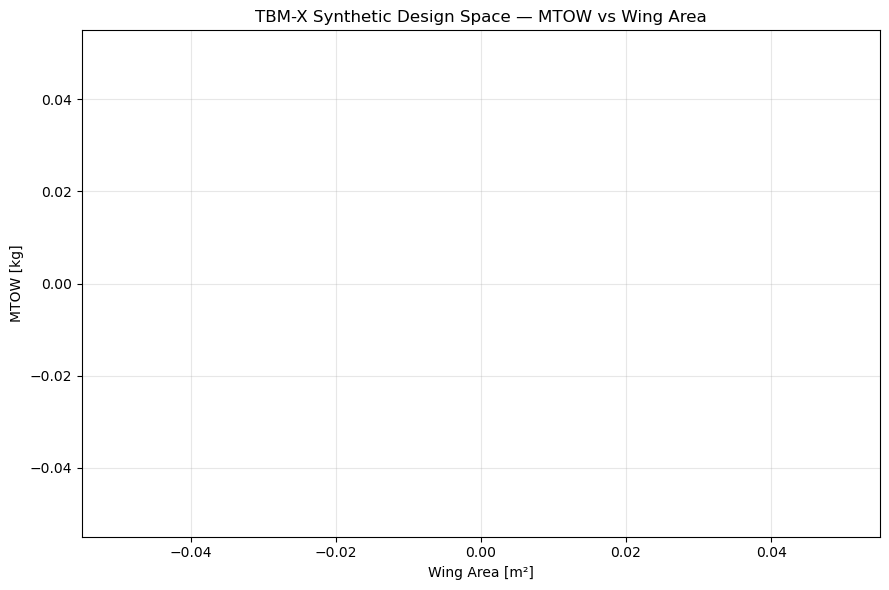

In [40]:
# ============================================================
# CELL 40 — DESIGN SPACE VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    valid_design_df["Wing_Area_m2"],
    valid_design_df["MTOW_kg"],
    s=8,
    alpha=0.35
)

plt.xlabel("Wing Area [m²]")
plt.ylabel("MTOW [kg]")
plt.title("TBM-X Synthetic Design Space — MTOW vs Wing Area")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**MTOW vs Required Power**

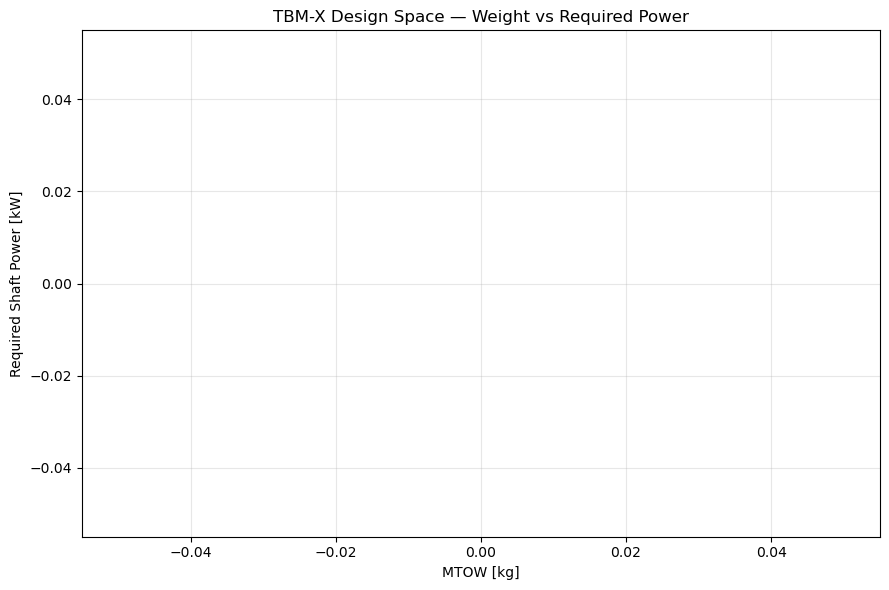

In [41]:
# ============================================================
# CELL 41 — MTOW vs REQUIRED POWER
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    valid_design_df["MTOW_kg"],
    valid_design_df["Required_Shaft_Power_kW"],
    s=8,
    alpha=0.35
)

plt.xlabel("MTOW [kg]")
plt.ylabel("Required Shaft Power [kW]")
plt.title("TBM-X Design Space — Weight vs Required Power")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**L/D Distribution**

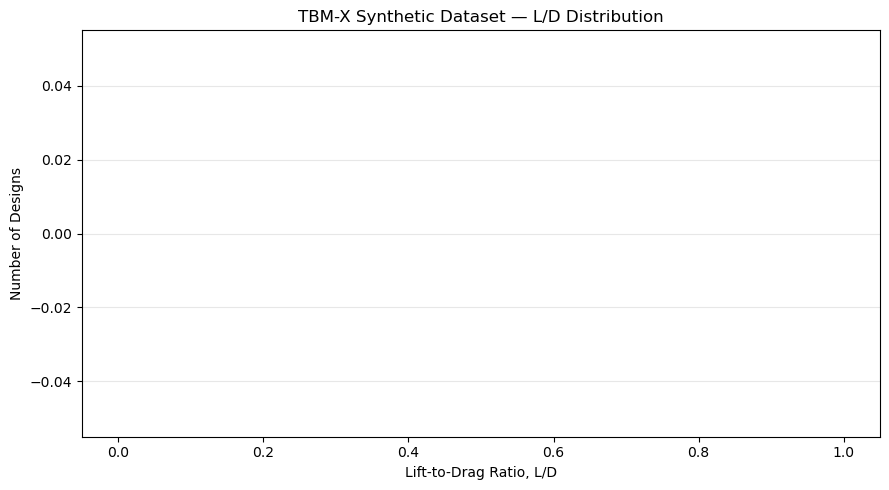

In [42]:
# ============================================================
# CELL 42 — L/D DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    valid_design_df["Lift_to_Drag"],
    bins=40
)

plt.xlabel("Lift-to-Drag Ratio, L/D")
plt.ylabel("Number of Designs")
plt.title("TBM-X Synthetic Dataset — L/D Distribution")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Required Power Distribution**

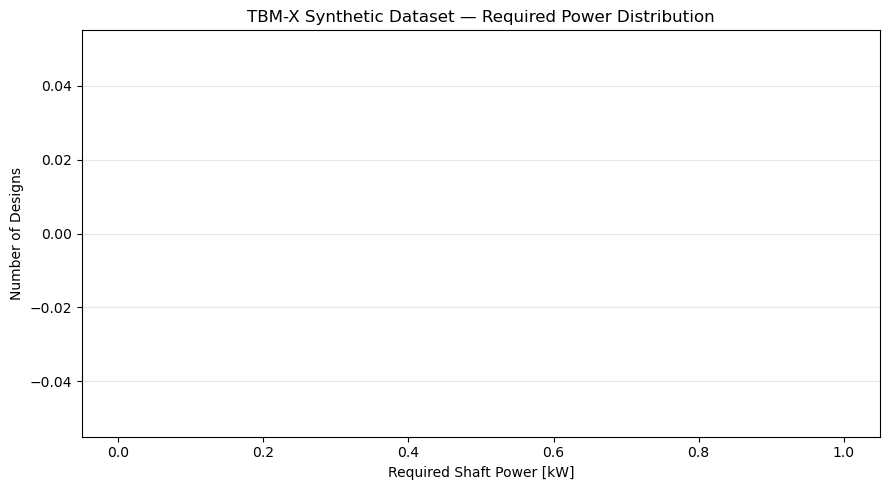

In [43]:
# ============================================================
# CELL 43 — REQUIRED POWER DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    valid_design_df[
        "Required_Shaft_Power_kW"
    ],
    bins=40
)

plt.xlabel("Required Shaft Power [kW]")
plt.ylabel("Number of Designs")
plt.title(
    "TBM-X Synthetic Dataset — Required Power Distribution"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Correlation Matrix**

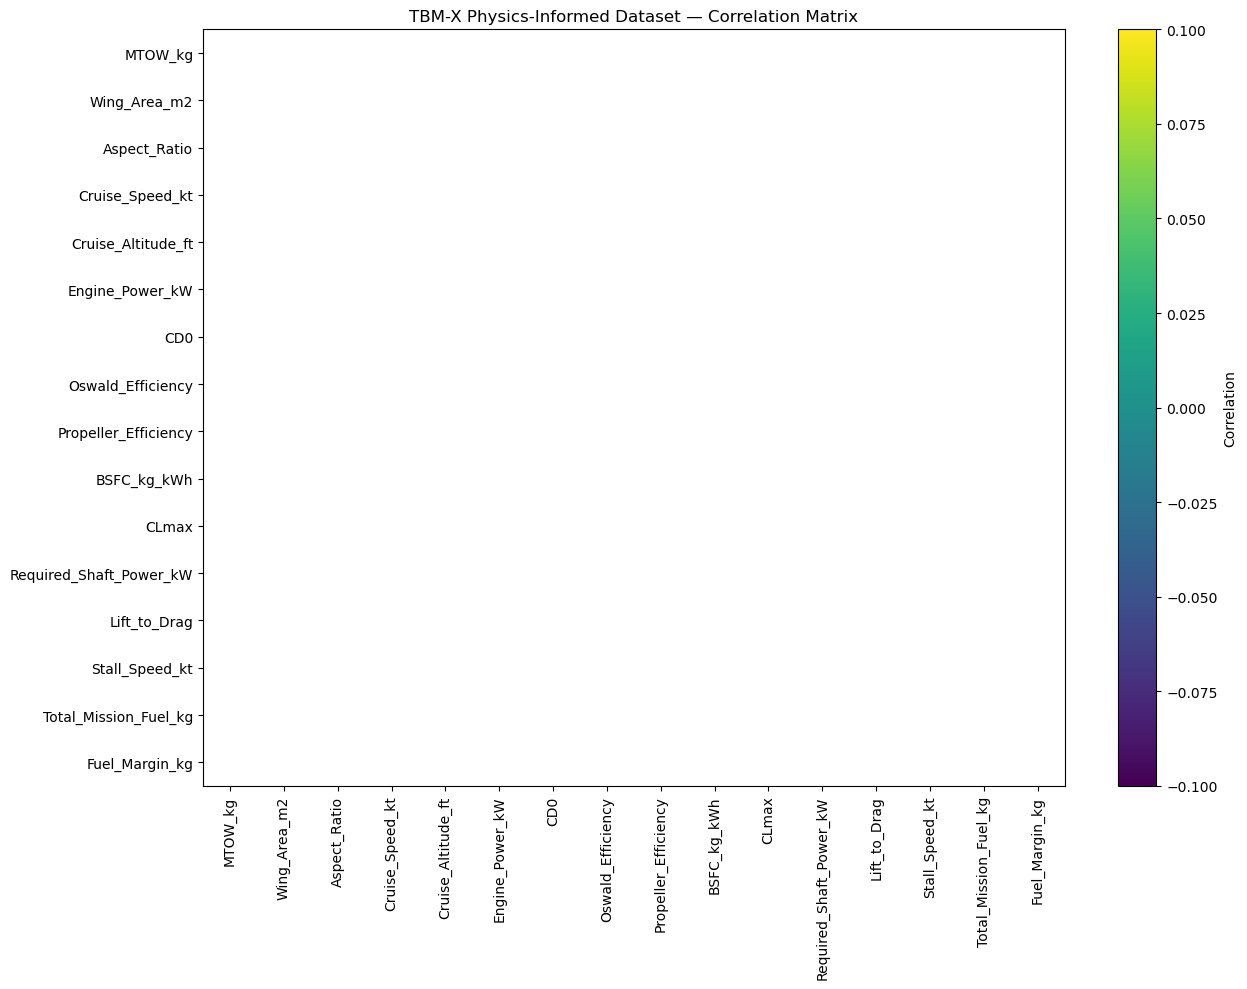

In [44]:
# ============================================================
# CELL 44 — CORRELATION MATRIX
# ============================================================

correlation_columns = (
    feature_columns
    + [
        "Required_Shaft_Power_kW",
        "Lift_to_Drag",
        "Stall_Speed_kt",
        "Total_Mission_Fuel_kg",
        "Fuel_Margin_kg",
    ]
)

correlation_matrix = (
    valid_design_df[
        correlation_columns
    ]
    .corr()
)

plt.figure(figsize=(13, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title(
    "TBM-X Physics-Informed Dataset — Correlation Matrix"
)

plt.tight_layout()
plt.show()

**Dataset Quality Report**

In [45]:
# ============================================================
# CELL 45 — DATASET QUALITY REPORT
# ============================================================

quality_report = pd.DataFrame({
    
    "Metric": [
        "Requested samples",
        "Generated samples",
        "Valid samples",
        "Feasibility rate [%]",
        "Missing cells",
        "Duplicate rows",
        "Feature count",
        "Target count",
    ],
    
    "Value": [
        N_SAMPLES,
        len(design_df),
        len(valid_design_df),
        feasibility_rate,
        int(valid_design_df.isna().sum().sum()),
        duplicate_count,
        len(feature_columns),
        len(target_columns),
    ]
})

quality_report

,Metric,Value
0,Requested samples,"10,000.0000"
1,Generated samples,"10,000.0000"
2,Valid samples,0.0000
3,Feasibility rate [%],0.0000
4,Missing cells,0.0000
5,Duplicate rows,0.0000
6,Feature count,11.0000
7,Target count,16.0000


**Save Full Dataset**

In [46]:
# ============================================================
# CELL 46 — SAVE LARGE DATASET
# ============================================================

dataset_path = (
    dataset_output_dir
    / "TBM_X_Large_Design_Dataset_v0_1.csv"
)

valid_design_df.to_csv(
    dataset_path,
    index=False
)

print("✓ Dataset saved:")
print(dataset_path)

print(
    f"\nRows    : {len(valid_design_df):,}"
)

print(
    f"Columns : {valid_design_df.shape[1]}"
)

✓ Dataset saved:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\data\generated\TBM_X_Large_Design_Dataset_v0_1.csv

Rows    : 0
Columns : 50


**Save Dataset Statistics**

In [47]:
# ============================================================
# CELL 47 — SAVE DATASET STATISTICS
# ============================================================

statistics_path = (
    dataset_output_dir
    / "TBM_X_Large_Dataset_Statistics_v0_1.csv"
)

dataset_statistics.to_csv(
    statistics_path
)

print("✓ Statistics saved:")
print(statistics_path)

✓ Statistics saved:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\data\generated\TBM_X_Large_Dataset_Statistics_v0_1.csv


**Save Quality Report**

In [48]:
# ============================================================
# CELL 48 — SAVE QUALITY REPORT
# ============================================================

quality_path = (
    dataset_output_dir
    / "TBM_X_Large_Dataset_Quality_v0_1.csv"
)

quality_report.to_csv(
    quality_path,
    index=False
)

print("✓ Quality report saved:")
print(quality_path)

✓ Quality report saved:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\data\generated\TBM_X_Large_Dataset_Quality_v0_1.csv


**Final Dataset Summary**

In [49]:
# ============================================================
# CELL 49 — FINAL DATASET SUMMARY
# ============================================================

print("=" * 70)
print("TBM-X — LARGE DATASET GENERATION COMPLETE")
print("=" * 70)

print(
    f"\nRequested designs       : {N_SAMPLES:,}"
)

print(
    f"Generated designs       : {len(design_df):,}"
)

print(
    f"Valid designs           : {len(valid_design_df):,}"
)

print(
    f"Feasibility rate        : {feasibility_rate:.2f}%"
)

print(
    f"Feature count           : {len(feature_columns)}"
)

print(
    f"Target count            : {len(target_columns)}"
)

print(
    f"\nDataset file:"
)

print(
    dataset_path
)

print("\nNext step:")
print(
    "→ EDA / Design Space Exploration"
)

print("=" * 70)

TBM-X — LARGE DATASET GENERATION COMPLETE

Requested designs       : 10,000
Generated designs       : 10,000
Valid designs           : 0
Feasibility rate        : 0.00%
Feature count           : 11
Target count            : 16

Dataset file:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\data\generated\TBM_X_Large_Design_Dataset_v0_1.csv

Next step:
→ EDA / Design Space Exploration


**Final Engineering Statement**

In [50]:
# ============================================================
# CELL 50 — ENGINEERING STATEMENT
# ============================================================

print("""
TBM-X Large Dataset v0.1 has been generated.

The dataset is PHYSICS-INFORMED:

    Design Variables
          ↓
    Aerodynamic Model
          ↓
    Propulsion Model
          ↓
    Mission Model
          ↓
    Feasibility Constraints
          ↓
    Synthetic Aircraft Designs

The synthetic data is NOT intended to replace real aircraft
measurements.

Real aircraft benchmark data remains the reality anchor.

The purpose of this dataset is to create a sufficiently large
and physically structured design space for:

    EDA
    ML / Surrogate Modeling
    UQ
    Optimization
    Engineering Decision

The next notebook will investigate the structure of this
design space before any machine-learning model is trained.
""")


TBM-X Large Dataset v0.1 has been generated.

The dataset is PHYSICS-INFORMED:

    Design Variables
          ↓
    Aerodynamic Model
          ↓
    Propulsion Model
          ↓
    Mission Model
          ↓
    Feasibility Constraints
          ↓
    Synthetic Aircraft Designs

The synthetic data is NOT intended to replace real aircraft
measurements.

Real aircraft benchmark data remains the reality anchor.

The purpose of this dataset is to create a sufficiently large
and physically structured design space for:

    EDA
    ML / Surrogate Modeling
    UQ
    Optimization
    Engineering Decision

The next notebook will investigate the structure of this
design space before any machine-learning model is trained.

